#### Load the Clean Dataset

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('C:/Users/nimma/Downloads/IDS-PROJECT/dataset/CICIDS2017_Clean.csv')

pd.set_option("display.max_columns", None)

#### Dataset Shape

In [4]:
print(df.shape)

print(df.columns)

(2520798, 71)
Index(['Destination Port', 'Flow Duration', 'Total Fwd Packets',
       'Total Backward Packets', 'Total Length of Fwd Packets',
       'Total Length of Bwd Packets', 'Fwd Packet Length Max',
       'Fwd Packet Length Min', 'Fwd Packet Length Mean',
       'Fwd Packet Length Std', 'Bwd Packet Length Max',
       'Bwd Packet Length Min', 'Bwd Packet Length Mean',
       'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s',
       'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min',
       'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max',
       'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std',
       'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Fwd URG Flags',
       'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s',
       'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length',
       'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance',
       'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PS

#### Statistical Summary

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Destination Port,2520798.0,8.690590e+03,1.901280e+04,0.0,53.0,80.0,443.0,65535.0
Flow Duration,2520798.0,1.659161e+07,3.523276e+07,-13.0,208.0,50622.0,5333340.5,119999998.0
Total Fwd Packets,2520798.0,1.028174e+01,7.944201e+02,1.0,2.0,2.0,6.0,219759.0
Total Backward Packets,2520798.0,1.157280e+01,1.056922e+03,0.0,1.0,2.0,5.0,291922.0
Total Length of Fwd Packets,2520798.0,6.119477e+02,1.058827e+04,0.0,12.0,66.0,332.0,12900000.0
...,...,...,...,...,...,...,...,...
Active Min,2520798.0,6.546359e+04,6.111585e+05,0.0,0.0,0.0,0.0,110000000.0
Idle Mean,2520798.0,9.337367e+06,2.484818e+07,0.0,0.0,0.0,0.0,120000000.0
Idle Std,2520798.0,5.657941e+05,4.874169e+06,0.0,0.0,0.0,0.0,76900000.0
Idle Max,2520798.0,9.763770e+06,2.561746e+07,0.0,0.0,0.0,0.0,120000000.0


#### Class Distribution

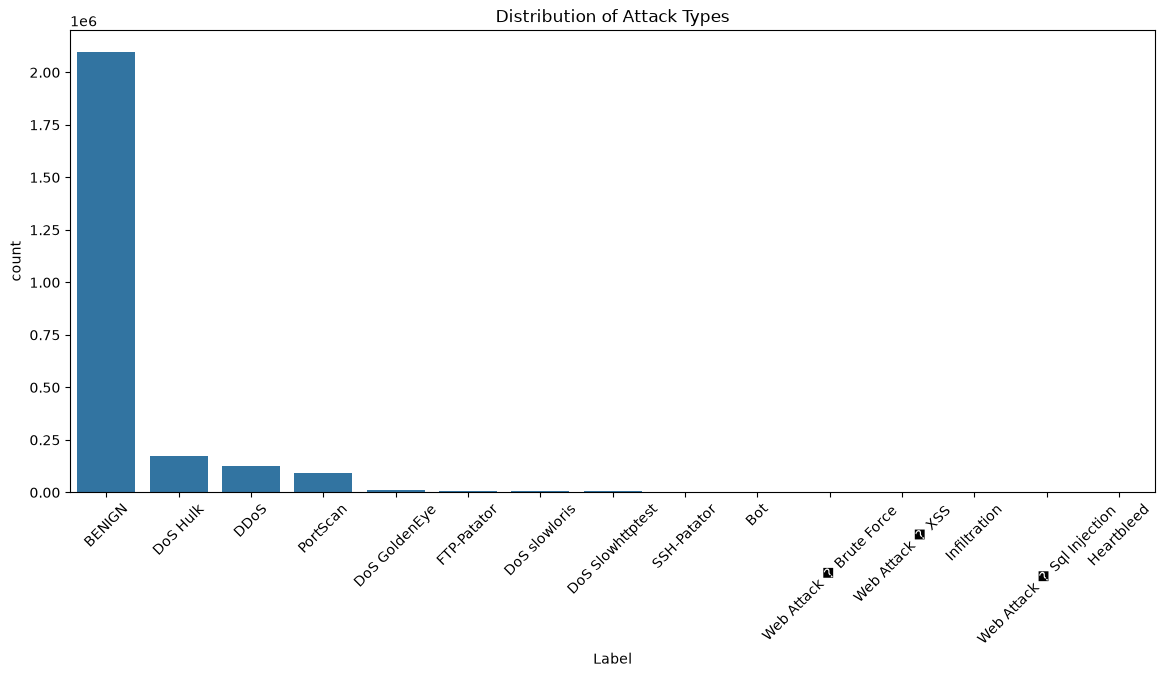

In [7]:
plt.figure(figsize=(14, 6))

sns.countplot(
    x='Label',
    data=df,
    order=df['Label'].value_counts().index
)

plt.xticks(rotation=45)
plt.title('Distribution of Attack Types')
plt.show()

#### Numerical Feature Distributions

In [8]:
numeric_cols = df.select_dtypes(include=[np.number]).columns

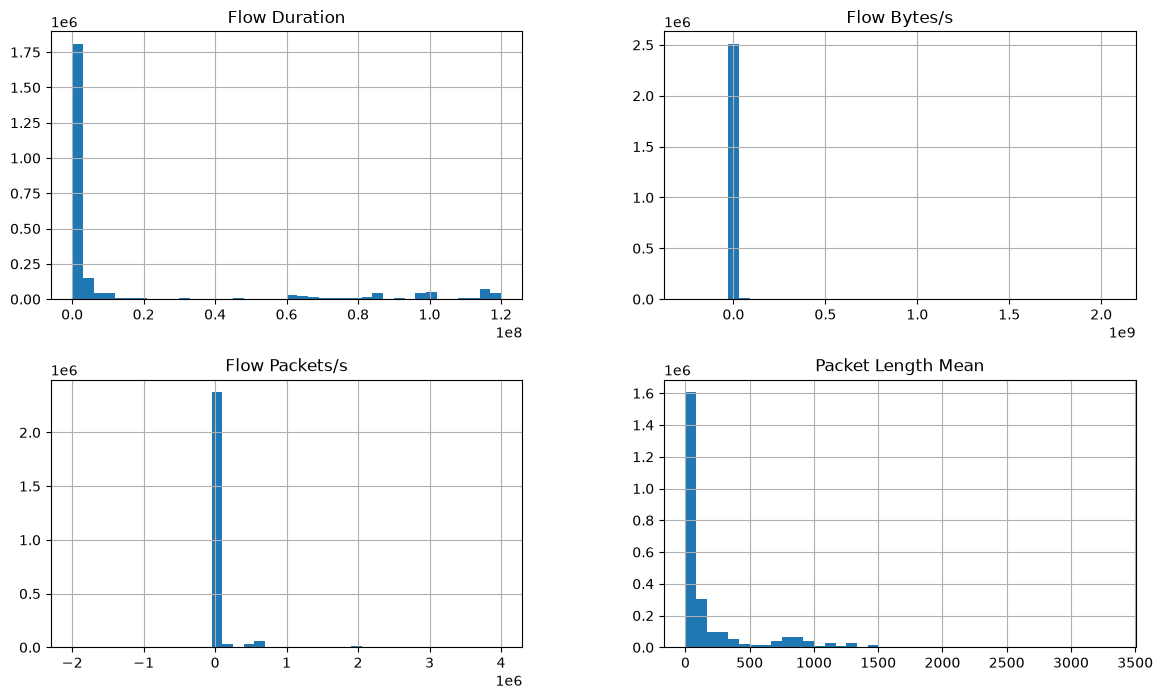

In [11]:
features = [
    'Flow Duration',
    'Flow Bytes/s',
    'Flow Packets/s',
    'Packet Length Mean',
]

df[features].hist(
    figsize=(14,8),
    bins=40
)

plt.show()

#### Boxplots

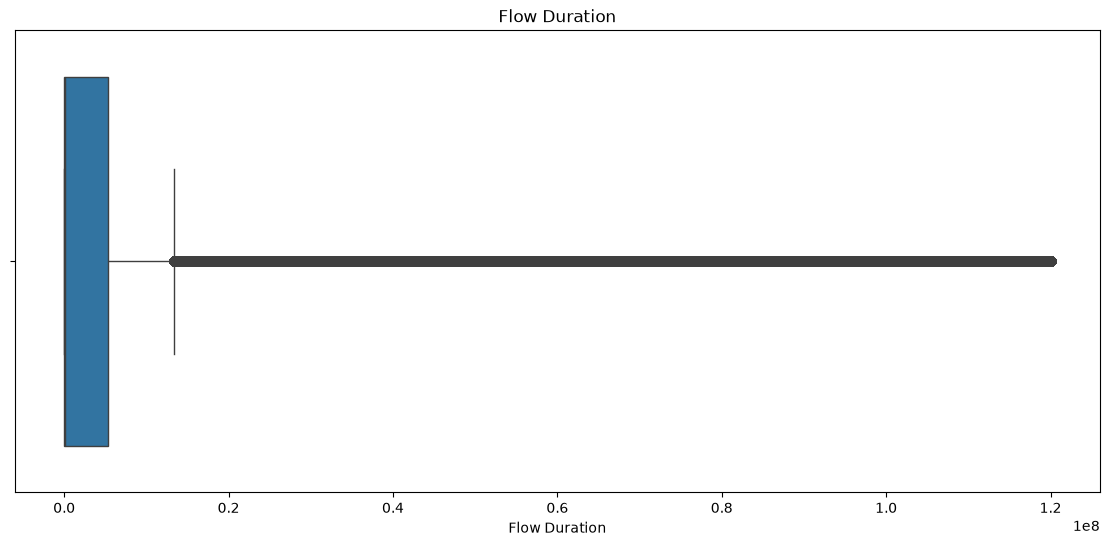

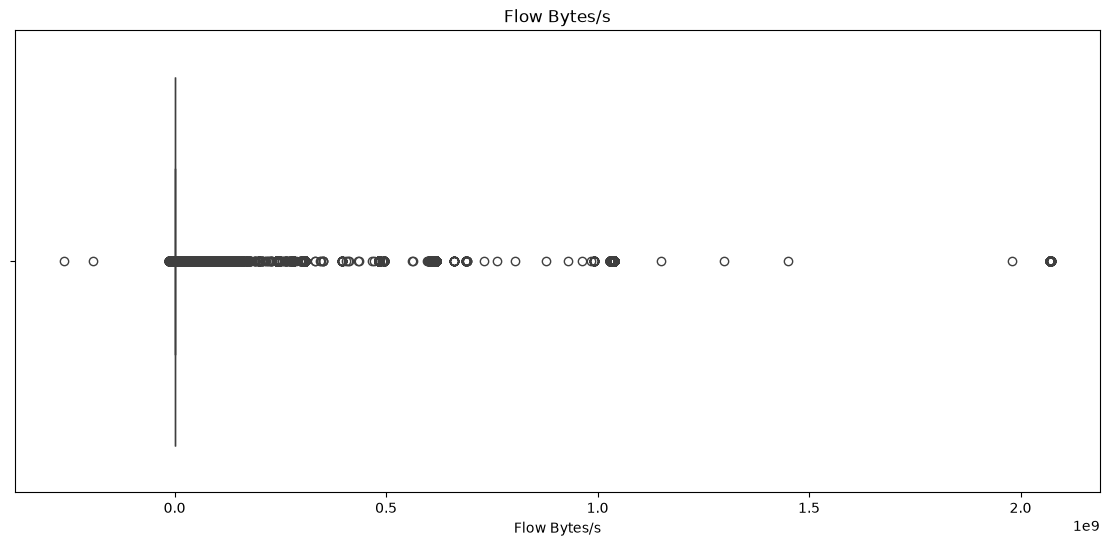

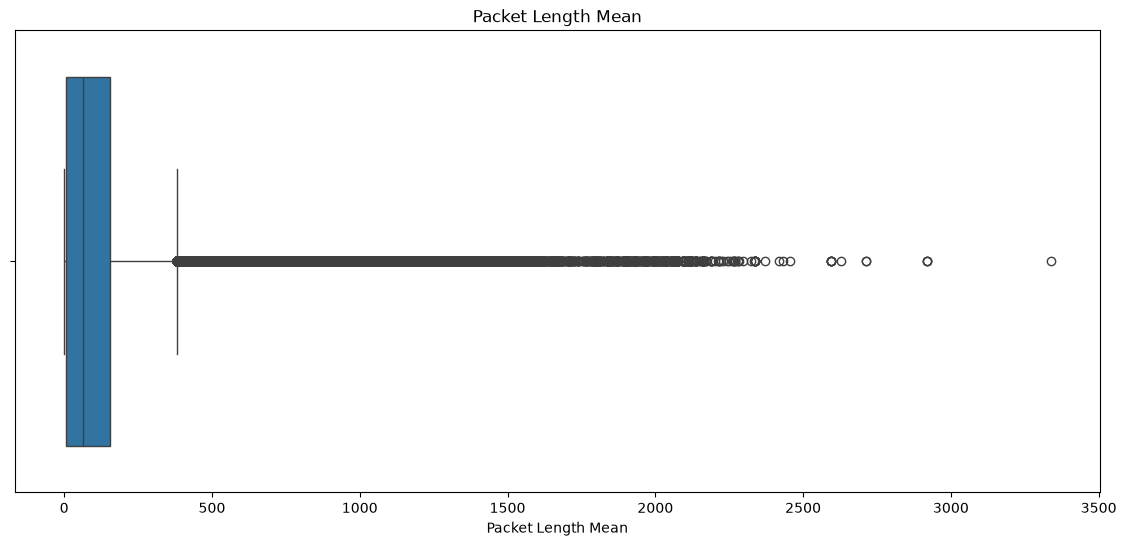

In [12]:
for feature in [
    'Flow Duration',
    'Flow Bytes/s',
    'Packet Length Mean',
]:
    plt.figure(figsize=(14,6))
    sns.boxplot(x=df[feature])
    plt.title(feature)
    plt.show()

#### Correlation Preview

In [13]:
corr = df.select_dtypes(include=[np.number]).corr()

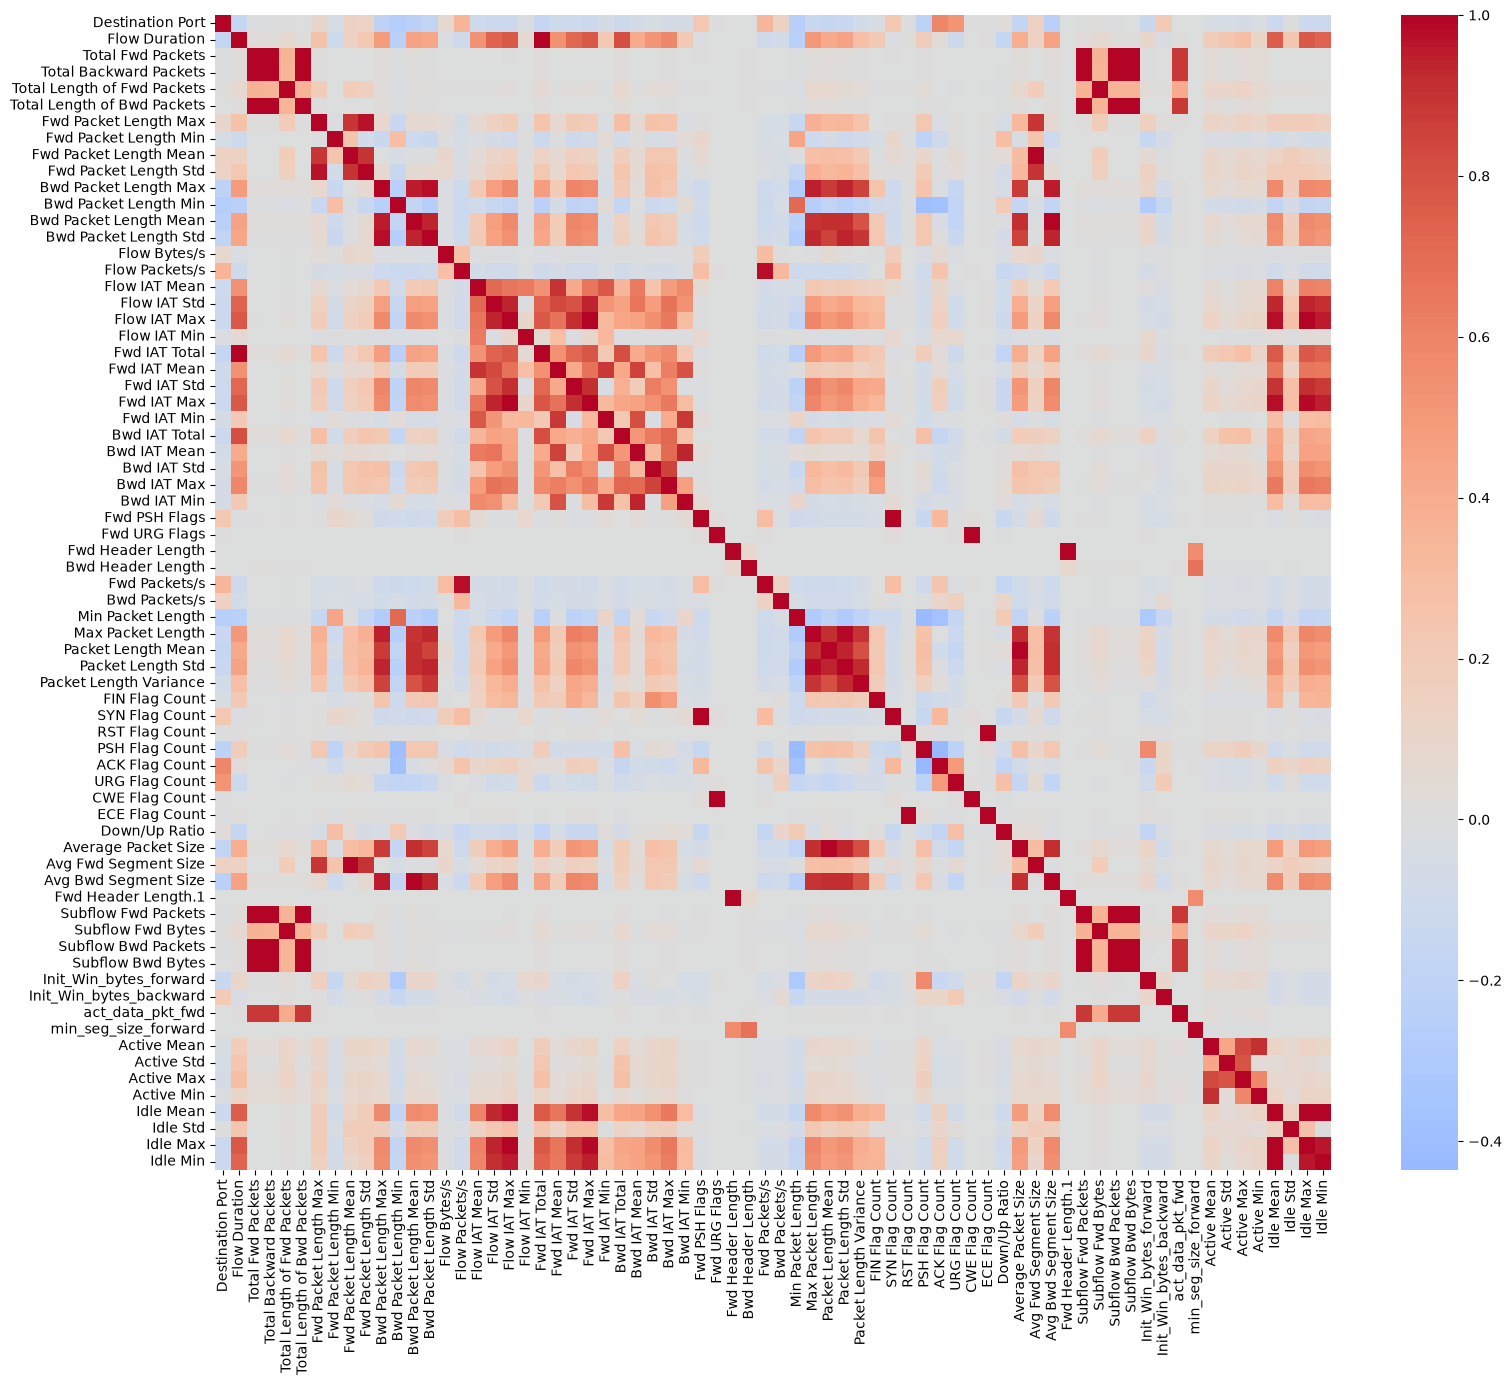

In [14]:
plt.figure(figsize=(18,15))

sns.heatmap(
    corr,
    cmap='coolwarm',
    center=0,
)

plt.show()

#### Unique Values

In [16]:
for col in df.columns:
    print(col, df[col].nunique())

Destination Port 53791
Flow Duration 1050898
Total Fwd Packets 1432
Total Backward Packets 1747
Total Length of Fwd Packets 17928
Total Length of Bwd Packets 64698
Fwd Packet Length Max 5279
Fwd Packet Length Min 384
Fwd Packet Length Mean 99716
Fwd Packet Length Std 253909
Bwd Packet Length Max 4838
Bwd Packet Length Min 583
Bwd Packet Length Mean 147614
Bwd Packet Length Std 248869
Flow Bytes/s 1593907
Flow Packets/s 1240163
Flow IAT Mean 1166310
Flow IAT Std 1056642
Flow IAT Max 580288
Flow IAT Min 136316
Fwd IAT Total 493098
Fwd IAT Mean 737737
Fwd IAT Std 700313
Fwd IAT Max 437316
Fwd IAT Min 110631
Bwd IAT Total 414928
Bwd IAT Mean 670824
Bwd IAT Std 709042
Bwd IAT Max 368285
Bwd IAT Min 66074
Fwd PSH Flags 2
Fwd URG Flags 2
Fwd Header Length 3771
Bwd Header Length 3945
Fwd Packets/s 1220423
Bwd Packets/s 1107886
Min Packet Length 215
Max Packet Length 5708
Packet Length Mean 215826
Packet Length Std 412246
Packet Length Variance 405565
FIN Flag Count 2
SYN Flag Count 2
RST Flag 

#### Feature Variance

In [17]:
df.var(numeric_only=True).sort_values()

Fwd URG Flags     3.173499e-05
CWE Flag Count    3.173499e-05
RST Flag Count    2.720621e-04
ECE Flag Count    2.732515e-04
FIN Flag Count    3.106529e-02
                      ...     
Fwd IAT Max       6.639125e+14
Flow Bytes/s      7.060096e+14
Bwd IAT Total     9.138067e+14
Fwd IAT Total     1.236674e+15
Flow Duration     1.241348e+15
Length: 70, dtype: float64